- https://www.arxiv.org/abs/2512.21852
    - k1 in reward
- http://joschu.net/blog/kl-approx.html
    - $q$: $\pi_\theta$，$p$: $\pi_{ref}$
    - k1/k2/k3
        - $k_1 = \log \frac{q(x)}{p(x)} = - \log r$
        - $k_2=\frac{1}{2}(\log\frac{p(x)}{q(x)})^2 = \frac 12(\log r)^2$
        - $k_3 = (r - 1) - \log r=\frac{p(x)}{q(x)}-1-\log\frac{p(x)}{q(x)}$
- references
    - https://xihuai18.github.io/reinforcement-learning/2025/12/01/kl-estimators-en.html
    - https://gemini.google.com/gem/a2386768353f/1aba00d79702d9de

### 蒙特卡洛估计

$$
D_{KL}(\pi_\theta || \pi_{ref}) = \sum_{x \in \mathcal{X}} \pi_\theta(x) \log \left( \frac{\pi_\theta(x)}{\pi_{ref}(x)} \right) = \mathbb{E}_{x \sim \pi_\theta} \left[ \log \left( \frac{\pi_\theta(x)}{\pi_{ref}(x)} \right) \right]
$$

- KL 散度无法精确计算，
    - $\mathcal{X}$ (样本空间)：对于 LLM 来说，这是所有可能的 token 序列的集合。假设词表大小 $|V|=10^5$，序列长度 $L=2048$，那么可能的序列总数是 $|V|^L$（天文数字）。无法遍历：我们无法遍历所有可能的 $x$ 来求和。
- 必须使用估计器 (Estimators)：只能使用蒙特卡洛估计 (Monte Carlo Estimation，蒙特卡洛估计期望)
    - 在实际训练中，我们只能拿到模型生成的一个 batch 的采样样本（Sampled Trajectories）。我们用这“几个样本”的均值来代替那个“天文数字”总和的期望值：
    - $D_{KL} \approx \frac{1}{N} \sum_{i=1}^N \log \frac{\pi_\theta(x_i)}{\pi_{ref}(x_i)}, \quad x_i \sim \pi_\theta$
        - $\mathbb{E}_{x \sim \pi_\theta} \left[ \log \frac{\pi_\theta(x)}{\pi_{ref}(x)} \right] \approx \frac{1}{N} \sum_{i=1}^{N} \log \frac{\pi_\theta(x_i)}{\pi_{ref}(x_i)}, \quad \text{其中 } x_i \text{ 是从 } \pi_\theta \text{ 采样出的样本}$
        - 虽然数学公式写的是 $x_i$（整句），但在代码里（无论是 PPO 还是 GRPO），我们实际上是在计算 Per-token KL Penalty。
            - 由于 $\log$ 的存在，这个关于“整句”的公式，在数学上等价于所有 Token 的 Log Probability Ratio 之和。
            - 我们计算的是 (log_probs - ref_log_probs)，这是一个形状为 `[Batch_Size, Sequence_Length]` 的张量。

$$\begin{aligned}
\log \frac{\pi_\theta(x_i)}{\pi_{ref}(x_i)} &= \log \left( \frac{\prod_{t} \pi_\theta(w_t|...)}{\prod_{t} \pi_{ref}(w_t|...)} \right) \\
&= \sum_{t=1}^{T} \log \frac{\pi_\theta(w_t | w_{<t})}{\pi_{ref}(w_t | w_{<t})} \\
&= \sum_{t=1}^{T} \underbrace{\left( \log \pi_\theta(w_t | \dots) - \log \pi_{ref}(w_t | \dots) \right)}_{\text{Per-token KL / K1 Estimator}}
\end{aligned}
$$

### K1/K3

在统计学中，如果我们想估计一个真实值 $\theta$（在这里 $\theta = D_{KL}(\pi_\theta || \pi_{ref})$），我们设计了一个估计器 $\hat{\theta}$（这里是 $k_1$ 或 $k_3$）。
- 无偏 (Unbiased)：指估计器的期望值等于真实值，即 $\mathbb{E}[\hat{\theta}] = \theta$。
- 有偏 (Biased)：指 $\mathbb{E}[\hat{\theta}] \neq \theta$。

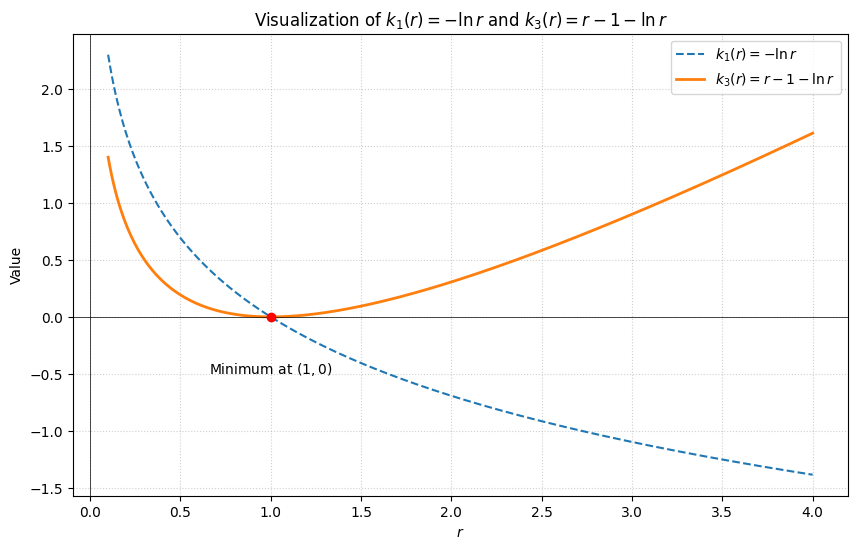

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define the range for r (must be > 0)
r = np.linspace(0.1, 4.0, 400)

# Define the functions
k1 = -np.log(r)
k3 = r - 1 - np.log(r)

# Plotting
plt.figure(figsize=(10, 6))

# Plot k1
plt.plot(r, k1, label=r'$k_1(r) = -\ln r$', linestyle='--')

# Plot k3
plt.plot(r, k3, label=r'$k_3(r) = r - 1 - \ln r$', linewidth=2)

# Highlight the convexity of k3
# We can mark the minimum at r=1
plt.scatter([1], [0], color='red', zorder=5)
plt.text(1, -0.5, r'Minimum at $(1, 0)$', horizontalalignment='center')

# Labels and Title
plt.title(r'Visualization of $k_1(r) = -\ln r$ and $k_3(r) = r - 1 - \ln r$')
plt.xlabel('$r$')
plt.ylabel('Value')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

- ratio: $r = \frac{\pi_\theta(a|s)}{\pi_{ref}(a|s)}$
- K1 估计器：朴素估计 (The Naive Estimator), $k_1(r) = \log(r) = \log \pi_\theta(a|s) - \log \pi_{ref}(a|s)$
    - 无偏性 (Unbiased)：它的期望值严格等于真实的 KL 散度。
    - 高方差：数值波动大。
    - 可负性：这是最大的缺点。如果模型采样到了一个在 Reference Model 中概率更高但在 Current Model 中概率较低的词，$k_1$ 就会变成负数。这意味着 KL Penalty（$-\beta \cdot KL$）变成了一个正向奖励，鼓励模型继续偏离！

$$
\begin{aligned}
\mathbb{E}_{x \sim \pi_\theta}[k_1(r)] &= \sum_{x} \pi_\theta(x) \cdot \log \left( \frac{\pi_\theta(x)}{\pi_{ref}(x)} \right) \\
&= D_{KL}(\pi_\theta || \pi_{ref})
\end{aligned}
$$

- K3 估计器：Schulman 估计器 (The "Positivity-Constrained" Estimator): $k_3(r) = (r - 1) - \log(r)$
    - 这是基于凸函数性质设计的。因为 $x - 1 \ge \log x$ 对所有 $x>0$ 成立，所以 $k_3(r)$ 恒大于等于 0。
        - 它利用 $x - 1 \ge \log x$ 这个不等式，强行把估计值“托举”到 0 以上，牺牲了数学上的精确对等（Bias），换取了训练时的数值稳定性（Low Variance & Positivity）。
    - 当 $\pi \approx \pi_{ref}$ ($r \approx 1$) 时，根据泰勒展开：$k_3(r) \approx \frac{1}{2}(r-1)^2 \approx \frac{1}{2}(\log r)^2$
    -  KL 散度在 $r=1$ 附近的二阶近似也是 $\frac{1}{2}(r-1)^2$。
- k3 特点
    - 恒正性 (Strictly Positive)：保证了 KL 惩罚项永远是惩罚，绝不会变成奖励。这极大地稳定了训练，防止模型钻空子。
    - 低方差：相比 K1，它的波动更小，尤其是在两个分布接近时。
    - 有偏 (Biased)：作为 Value 的估计它是无偏的（在某些特定的积分定义下），但作为梯度来源时，它与标准 KL 的梯度略有不同（但在 $\pi \approx \pi_{ref}$ 时非常接近）。
    $$
    \mathbb{E}_{x \sim \pi_\theta}[k_3(r)] = \underbrace{\mathbb{E}_{x \sim \pi_\theta}[r]}_{\text{项 A}} - 1 - \underbrace{\mathbb{E}_{x \sim \pi_\theta}[\log r]}_{\text{项 B}}
    $$
    - “项 B”：$\mathbb{E}[\log r] = D_{KL}(\pi_\theta || \pi_{ref})$。这部分就是 KL。

### in loss vs. in reward

- in reward: 将 KL 惩罚直接减去，作为总 Reward 的一部分传给 Critic/Advantage 计算。
    - PPO (Standard)
    - K3 (因其恒正性，能防止 Value Function 学习到错误的“奖励”信号)
- in loss: 不改变 Reward，而是作为额外的 Loss 项直接加在 Policy Loss 上进行梯度回传。
    - GRPO/DPO 隐式
        - $\max_{\pi} \mathbb{E} [r(x, y)] - \beta \mathbb{D}_{KL}(\pi || \pi_{ref})$
    - K1 (因为直接求导 $\nabla \log r$ 等价于标准 KL 梯度)

### k1 in reward

In [3]:
from IPython.display import Image

In [4]:
Image(url='./imgs/k1-reward.png', width=400)

### 梯度视角

> Path-wise Derivative & Score Function

假设模型是一个射箭运动员，他的每一次射箭都有随机性。
- $\theta$ (Theta)：运动员的姿势参数（我们要训练的东西）。
- $y$ (Sample)：射出的箭落在哪（采样结果）。
- $f(y)$ (Function)：得分规则（比如离靶心越近分越高）。
- 我们的目标是：调整姿势 $\theta$，让平均得分（期望 $\mathbb{E}$）变高。难点在于：射箭这个过程是随机的。我们怎么知道怎么微调姿势，才能让“平均分”变高？这就需要计算梯度。

$$
\nabla J(\theta) \approx \text{Reward}(y) \times \nabla \log(\text{Probability of } y)
$$

- Score Function Estimator: REINFORCE，
    - 它不需要知道 $f(y)$ 内部长什么样（不需要 $f(y)$ 可导）。它只关心结果（Reward）和概率。
    - 把 KL 散度当作一个惩罚项 (Penalty) 加到 Reward 里时，用的就是这种方法。
    - 这是“结果导向”的教学法。 作为教练，你并不懂空气动力学，也不懂肌肉力学。你只看结果：
        - 让运动员射一箭。
        - 如果得了高分（Reward 高），你就告诉他：“刚才那个动作不错，记住那个感觉，下次增加做这个动作的概率！”
        - 如果得了低分，你就说：“刚才那个动作不行，下次减少做这个动作的概率！”
$$
\nabla J(\theta) \approx \nabla_\theta f(y(\theta))
$$

- Path-wise Derivative（路径导数）
    - 这是“白盒分析”的教学法。作为教练，你拥有上帝视角。你知道风速、重力公式、以及运动员肌肉每一寸收缩如何精确地影响箭的轨迹。你不再依赖随机的“试一试”，而是直接计算：“如果把手抬高 1 毫米（改变 $\theta$），根据物理公式（Function），箭就会向上偏 2 厘米，得分就会增加 5 分。”
    - 当你把 KL 散度直接加到 Loss Function (损失函数) 里，利用 PyTorch/TensorFlow 的自动求导机制时，你用的就是这种方法。

$$
\mathbb{E}[\nabla] \neq \nabla \mathbb{E}
$$

- $\nabla D_{KL} = \mathbb{E}_{x \sim \pi_\theta} \left[ \log \frac{\pi_\theta}{\pi_{ref}} \cdot \nabla \log \pi_\theta \right]$
    - $D_{KL}(\pi_\theta || \pi_{ref}) = \int \pi_\theta(x) \log \frac{\pi_\theta(x)}{\pi_{ref}(x)} \, dx$
    - $\nabla_\theta D_{KL} = \int \underbrace{\nabla_\theta \pi_\theta(x)}_{\text{项 A}} \cdot \log \frac{\pi_\theta(x)}{\pi_{ref}(x)} \, dx + \int \pi_\theta(x) \cdot \underbrace{\nabla_\theta \left( \log \frac{\pi_\theta(x)}{\pi_{ref}(x)} \right)}_{\text{项 B}} \, dx$
    - $\text{项 A部分} = \int \pi_\theta(x) \nabla_\theta \log \pi_\theta(x) \cdot \log \frac{\pi_\theta(x)}{\pi_{ref}(x)} \, dx= \mathbb{E}_{x \sim \pi_\theta} \left[ \nabla_\theta \log \pi_\theta(x) \cdot \log \frac{\pi_\theta(x)}{\pi_{ref}(x)} \right]$
    - $\text{项 B部分} = \int \pi_\theta(x) \cdot \nabla_\theta (\log \pi_\theta(x) - \log \pi_{ref}(x)) \, dx$
        - $= \int \pi_\theta(x) \cdot \frac{\nabla_\theta \pi_\theta(x)}{\pi_\theta(x)} \, dx=\int \nabla_\theta \pi_\theta(x) \, dx= \nabla_\theta \int \pi_\theta(x) \, dx= \nabla_\theta (1) = 0$
- 这个梯度的形式和 REINFORCE 算法（策略梯度）非常相似，只不过它的“奖励”信号变成了 $\log(\pi_\theta / \pi_{ref})$。

$$
\mathbb{E}_{y \sim \pi_\theta} [ K1 \cdot \nabla_\theta \log \pi_\theta ] = \mathbb{E}_{y \sim \pi_\theta} \left[ \log \frac{\pi_\theta}{\pi_{ref}} \nabla_\theta \log \pi_\theta \right]
$$
- 当 K1 被放入 Reward（Reward Shaping） 时，我们利用的是 Score Function 梯度估计（REINFORCE）：这完全匹配 Reverse KL 梯度的真实定义。因此是无偏的 (Unbiased)。
$$
\begin{aligned}
\mathbb{E}_{y\sim\pi_\theta}[\nabla_\theta K1] &= \mathbb{E}[\nabla_\theta(\log \pi_\theta - \log \pi_{ref})] \\
&= \mathbb{E}[\nabla_\theta \log \pi_\theta] \quad (\pi_{ref} \text{ 固定}) \\
&= \sum \pi_\theta \frac{\nabla \pi_\theta}{\pi_\theta} = \sum \nabla \pi_\theta = \nabla 1 = 0
\end{aligned}
$$
- 当 K1 直接放入 Loss 进行自动微分（Path-wise derivative）时：期望梯度为 0（论文所谓的 Comedy）。实际上你只是在优化噪声，没有任何有效的梯度信号。
$$
\begin{aligned}
\mathbb{E}[\nabla_\theta K3] &= \mathbb{E}\left[\nabla_\theta\left(\frac{\pi_{ref}}{\pi_\theta}\right)\right] \quad (\text{忽略常数和 } \nabla \log r \text{ 为 } 0) \\
&= \mathbb{E}\left[- \frac{\pi_{ref}}{\pi_\theta^2} \nabla_\theta \pi_\theta\right] = \mathbb{E}\left[- \frac{\pi_{ref}}{\pi_\theta} \nabla_\theta \log \pi_\theta\right] \\
&= \sum \pi_\theta \left(- \frac{\pi_{ref}}{\pi_\theta}\right)\nabla \log \pi_\theta = - \sum \pi_{ref} \nabla \log \pi_\theta
\end{aligned}
$$
- k3 in loss, 期望变为对 $\pi_{ref}$ 的求和，这正是 Forward KL $\nabla D_{KL}(\pi_{ref}\|\pi_\theta)$ 的梯度形式（Mode Covering）。虽然有偏，但具有物理意义，因此训练稳定。
    - $\begin{aligned}
\nabla_\theta D_{KL}(\pi_{ref} \| \pi_\theta) &= \nabla_\theta \left( \sum \pi_{ref} \log \pi_{ref} - \sum \pi_{ref} \log \pi_\theta \right) \\
&= 0 - \sum \pi_{ref} \nabla_\theta \log \pi_\theta \\
&= - \sum \pi_{ref} \nabla_\theta \log \pi_\theta
\end{aligned}$
$$
\mathbb{E}[K3 \cdot \nabla \log \pi_\theta] = \mathbb{E}\left[\left(\frac{\pi_{ref}}{\pi_\theta} - 1 - \log \frac{\pi_{ref}}{\pi_\theta}\right)\nabla \log \pi_\theta\right]
$$
- k3 in reward, 相比 K1 (只有 $\log$ 项)，这里多出了 $\frac{\pi_{ref}}{\pi_\theta}$ 项 (Importance Sampling Ratio)。当 $\pi_\theta(y)$ 很小（模型认为该 token 概率低）但 $\pi_{ref}(y)$ 不为 0 时，该比值会趋向于无穷大。结论：引入了无界的偏差项，导致极大的梯度方差，训练迅速崩溃。

### k3 in loss

> 标准的 Knowledge Distillation (KD) 通常使用的是 Forward KL Divergence (前向 KL 散度)。

- K3 in Loss 的梯度是有偏的（biased），但它实际上近似于 Forward KL $KL(\pi_{ref}\|\pi_\theta)$ 的梯度，类似于 Logit Distillation。
    - This may be explained by the observation that the gradient estimate (16) in this case is a sum of unbiased gradient estimates of the forward KL divergences computed at the token level, making this configuration equivalent to a stable forward KL-based logit distillation objective trained on-policy, with the base model as a teacher.
    - Logit 蒸馏通常是指让学生模型（这里是 $\pi_\theta$）去模仿教师模型（这里是 $\pi_{ref}$）的输出概率分布。最小化 Forward KL 正是让 $\pi_\theta$ 尽可能接近 $\pi_{ref}$ 的分布。因此，文章指出，K3 in Loss 实际上变成了一个以此前生成的 token 为条件的、以 Base Model 为 Teacher 的 Logit 蒸馏任务。

### misc

- k2 estimator
    - 